## Bioinformatics: Computational Drug Discovery
### Regression Models with Random Forest

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [13]:
## -- Load Dataset -- ##
df = pd.read_csv('data/acetylcholinesterase_activity_06_pubchem_pic50_modeldata.csv')
# remove rows in which target has missing values
df = df.dropna(subset=['pIC50']).copy()
print(f"Dataset shape: {df.shape}")

Dataset shape: (5350, 882)


In [14]:
# Dataset contains 881 features and 1 target variable (pIC50). 
# The features are molecular descriptors calculated using PaDEL-Descriptor. 
# The target variable is the negative logarithm of the IC50 value, which represents the potency of a compound in inhibiting acetylcholinesterase.
df_x = df.drop(columns=['pIC50'])
df_y = df['pIC50']

In [15]:
print(f"Features shape: {df_x.shape}, Target shape: {df_y.shape}")

Features shape: (5350, 881), Target shape: (5350,)


Features with almost no variation (e.g. sensors that always reads the same value) can drag down model performance. Low variance filters weed out these “static” features, helping models focus on what really matters and boosting their predictive power.

In [16]:
# Remove low variance features (variance < 0.01)
from sklearn.feature_selection import VarianceThreshold
selection = VarianceThreshold(threshold=(.8 * (1 - .8)))   
df_x = selection.fit_transform(df_x)
df_x.shape

(5350, 144)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((4280, 144), (1070, 144), (4280,), (1070,))

In [18]:
# Build a Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
r2_score = model.score(x_test, y_test)
print(f"Model R^2 score: {r2_score:.4f}")

Model R^2 score: 0.7422


In [19]:
y_pred = model.predict(x_test)
y_pred

array([6.80374648, 3.49508863, 6.58118847, ..., 6.44081281, 6.90415769,
       4.4226117 ], shape=(1070,))

### Scatterplot of Experimental vs. Predicted pIC50 Values

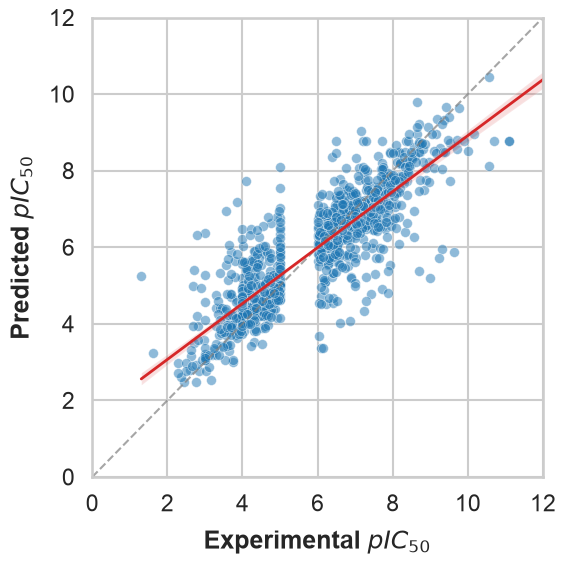

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use modern theme setting with clean gridlines
sns.set_theme(style="whitegrid", context="talk")

# 2. Set up the figure with high resolution (dpi) and tight layout
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)

# 3. Plot a dashed identity line (y = x) BEFORE the data so it sits in the background
ax.plot([0, 12], [0, 12], linestyle="--", color="gray", alpha=0.7, linewidth=1.5)

# 4. Create the regression plot with keyword arguments and enhanced marker styling
sns.regplot(
    x=y_test,
    y=y_pred,
    ax=ax,
    scatter_kws={
        "alpha": 0.5,
        "color": "#1f77b4",
        "edgecolor": "w",
        "linewidths": 0.5,
        "s": 50,
    },
    line_kws={"color": "#d62728", "linewidth": 2},  # Distinct color for regression line
)

# 5. Perfect the labels and limits
ax.set_xlabel("Experimental $pIC_{50}$", fontweight="bold", labelpad=10)
ax.set_ylabel("Predicted $pIC_{50}$", fontweight="bold", labelpad=10)
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

# Ensure everything fits perfectly inside the frame
plt.tight_layout()
plt.show()

In [28]:
# Define and build lazyclassifier model
import lazypredict
from lazypredict.Supervised import LazyRegressor

x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=42)

clf = LazyRegressor(verbose=0,ignore_warnings=True, custom_metric=None)

models, predictions = clf.fit(x_train, x_test, y_train, y_test)
#models_test, predictions_test = clf.fit(x_train, x_test, y_train, y_test)

In [29]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
RandomForestRegressor,0.702074,0.742206,0.893505,1.916272
BaggingRegressor,0.684360,0.726878,0.919685,0.202418
HistGradientBoostingRegressor,0.644097,0.692039,0.976581,0.425370
MLPRegressor,0.634035,0.683333,0.990290,1.026341
ExtraTreesRegressor,0.576616,0.633648,1.065148,2.743611
SVR,0.572933,0.630461,1.069770,0.607332
DecisionTreeRegressor,0.568588,0.626701,1.075199,0.037084
KNeighborsRegressor,0.566027,0.624485,1.078386,0.016660
NuSVR,0.565961,0.624428,1.078468,0.485082
